# HW4 — Sequence Modeling: Financial Forecasting
**CS515 Deep Learning | Sabanci University**

Bu notebook:
1. Repoyu çeker ve uv ile eksik bağımlılıkları kurar
2. Part b (exact return), Part c (rolling return), Part d (turning point) deneylerini GPU üzerinde çalıştırır
3. Sonuçları gösterir ve indirmeye hazırlar

> **Önemli:** Runtime → Change runtime type → **T4 GPU** seçili olmalı.

## 0. GPU Kontrolü

In [1]:
import torch

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: GPU yok — Runtime menüsünden T4 GPU seç!')

CUDA available : True
GPU            : NVIDIA A100-SXM4-40GB
VRAM           : 42.4 GB


## 1. Repo Kurulumu

In [2]:
import os

REPO_URL = 'https://github.com/caltinuzengi/cs515-deep-learning.git'
REPO_DIR = 'cs515-deep-learning'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print('Repo is already exist, being updated...')
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print(f'Directory: {os.getcwd()}')

Cloning into 'cs515-deep-learning'...
remote: Enumerating objects: 420, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 420 (delta 18), reused 27 (delta 15), pack-reused 378 (from 3)
Receiving objects: 100% (420/420), 507.74 MiB | 17.24 MiB/s, done.
Resolving deltas: 100% (87/87), done.
Updating files: 100% (270/270), done.
Directory: /content/cs515-deep-learning


## 2. Bağımlılık Kurulumu (uv)

Colab'ın CUDA-enabled torch'u korunur; sadece eksik paketler eklenir.

In [3]:
# uv'yi kur (PyPI üzerinden)
!pip install uv -q

# Eksik paketleri sistem Python'una ekle (Colab'ın torch/CUDA'sını değiştirmez)
!uv pip install --system yfinance scikit-learn ptflops -q

# Doğrula
import yfinance, sklearn
print(f'yfinance   : {yfinance.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'torch      : {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 114.0 MB/s eta 0:00:00
yfinance   : 0.2.66
scikit-learn: 1.6.1
torch      : 2.11.0+cu128


## 3. Veri İndirme ve Doğrulama

In [4]:
!python hw4/data_pipeline.py

=== Downloading data ===
  AAPL: 1508 rows → data/stocks/raw/AAPL.csv
  MSFT: 1508 rows → data/stocks/raw/MSFT.csv
  GOOGL: 1508 rows → data/stocks/raw/GOOGL.csv

=== ReturnDataset (exact) ===
  train: 3399 samples
  val  : 318 samples
  test : 735 samples

=== ReturnDataset (rolling) ===
  train: 3399 samples
  val  : 318 samples
  test : 735 samples

=== TurningPointDataset ===
  train: 3399 samples  |  class 1: 113 (3.3%)  class 0: 3286 (96.7%)
  val  : 318 samples  |  class 1: 7 (2.2%)  class 0: 311 (97.8%)
  test : 735 samples  |  class 1: 32 (4.4%)  class 0: 703 (95.6%)

=== Batch shapes ===
  X:         (64, 20, 4)
  y_exact:   (64, 5)
  y_rolling: (64, 5)
  y_binary:  (64, 1)


## 4. Part b — Exact Return Forecasting (StockLSTM & StockGRU)

In [5]:
!python hw4/experiment_b.py --retrain

device: cuda
loading data...

[StockLSTM] training...
Epoch   1/100 * | train=0.001627 | val=0.000693 | best=1
Epoch   2/100 * | train=0.001164 | val=0.000681 | best=2
Epoch   3/100 * | train=0.001118 | val=0.000669 | best=3
Epoch   4/100 * | train=0.001113 | val=0.000629 | best=4
Epoch   5/100   | train=0.001088 | val=0.000642 | best=4
Epoch   6/100   | train=0.001078 | val=0.000651 | best=4
Epoch   7/100   | train=0.001071 | val=0.000663 | best=4
Epoch   8/100   | train=0.001067 | val=0.000712 | best=4
Epoch   9/100 * | train=0.001073 | val=0.000623 | best=9
Epoch  10/100   | train=0.001065 | val=0.000634 | best=9
Epoch  11/100   | train=0.001055 | val=0.000687 | best=9
Epoch  12/100   | train=0.001052 | val=0.000685 | best=9
Epoch  13/100   | train=0.001053 | val=0.000650 | best=9
Epoch  14/100   | train=0.001048 | val=0.000684 | best=9
Epoch  15/100   | train=0.001050 | val=0.000664 | best=9
Epoch  16/100   | train=0.001048 | val=0.000661 | best=9
Epoch  17/100   | train=0.001044 |

## 5. Part c — Rolling Average Return Forecasting

In [6]:
!python hw4/experiment_c.py --retrain

device: cuda
loading data...

[StockLSTM] training...
Epoch   1/100 * | train=0.001033 | val=0.000293 | best=1
Epoch   2/100   | train=0.000565 | val=0.000316 | best=1
Epoch   3/100 * | train=0.000525 | val=0.000282 | best=3
Epoch   4/100 * | train=0.000509 | val=0.000277 | best=4
Epoch   5/100   | train=0.000491 | val=0.000283 | best=4
Epoch   6/100   | train=0.000486 | val=0.000288 | best=4
Epoch   7/100   | train=0.000478 | val=0.000289 | best=4
Epoch   8/100   | train=0.000473 | val=0.000323 | best=4
Epoch   9/100 * | train=0.000477 | val=0.000272 | best=9
Epoch  10/100   | train=0.000467 | val=0.000275 | best=9
Epoch  11/100   | train=0.000461 | val=0.000295 | best=9
Epoch  12/100   | train=0.000460 | val=0.000307 | best=9
Epoch  13/100   | train=0.000459 | val=0.000296 | best=9
Epoch  14/100   | train=0.000455 | val=0.000292 | best=9
Epoch  15/100   | train=0.000457 | val=0.000294 | best=9
Epoch  16/100   | train=0.000455 | val=0.000288 | best=9
Epoch  17/100   | train=0.000451 |

## 6. Part d — Turning Point Detection (BiStockLSTM & BiStockGRU)

In [ ]:
# Baseline: gamma=1.10 (10% gain threshold), loss-based early stopping, patience=10
!python hw4/experiment_d.py --retrain

### Part d — Additional Experiments: GAMMA & Early Stopping Ablation

The baseline (γ=1.10, loss-based stopping) yields a degenerate all-class-0 classifier.
Three ablations investigate two remedies: lowering the buy threshold to increase positive sample count, and switching to F1-based early stopping so the model is checkpointed on the metric that actually matters.

| Run tag | γ | patience | val_metric | Hypothesis |
|---------|---|----------|------------|------------|
| `g105_loss` | 1.05 | 10 | loss | 5% threshold → ~6% positives → richer gradient signal |
| `g110_f1`   | 1.10 | 5  | f1  | F1-based stopping avoids premature class-0 collapse |
| `g105_f1`   | 1.05 | 5  | f1  | Lower threshold + F1 stopping combined |

In [ ]:
# Experiment 1: gamma=1.05 (5% gain threshold) — more positive training samples
!python hw4/experiment_d.py --retrain --gamma 1.05

In [ ]:
# Experiment 2: gamma=1.10 + F1-based early stopping + patience=5
!python hw4/experiment_d.py --retrain --patience 5 --val-metric f1

In [ ]:
# Experiment 3: gamma=1.05 + F1-based early stopping + patience=5 (combined)
!python hw4/experiment_d.py --retrain --gamma 1.05 --patience 5 --val-metric f1

In [ ]:
# All Part d runs accumulated — compare gamma and early-stopping variants side by side
!python hw4/experiment_d.py

## 7. Sonuçlar — Metrikler

In [ ]:
import json, glob

for path in sorted(glob.glob('results/hw4/metrics/*.json')):
    with open(path) as f:
        data = json.load(f)
    print(f"\n{'='*55}")
    print(f"  {os.path.basename(path)}")
    print(f"{'='*55}")
    print(f"  model      : {data.get('model', '?')}")
    print(f"  best_epoch : {data.get('best_epoch', '?')}")
    if 'mean_mse' in data:
        print(f"  mean_mse   : {data['mean_mse']:.6f}")
        mse_str = ', '.join(f'd{i+1}={v:.4f}' for i, v in enumerate(data['per_horizon_mse']))
        print(f"  per horizon: {mse_str}")
        if data.get('stability_std') is not None:
            print(f"  stab_std   : {data['stability_std']:.6f}")
    if 'f1' in data:
        if data.get('run_tag'):
            print(f"  run_tag    : {data['run_tag']}  "
                  f"(gamma={data.get('gamma')}  patience={data.get('patience')}  "
                  f"val_metric={data.get('val_metric')})")
        print(f"  accuracy   : {data['accuracy']:.4f}")
        print(f"  precision  : {data['precision']:.4f}")
        print(f"  recall     : {data['recall']:.4f}")
        print(f"  f1         : {data['f1']:.4f}")
        cm = data['confusion_matrix']
        print(f"  conf_mat   : TN={cm[0][0]}  FP={cm[0][1]}  FN={cm[1][0]}  TP={cm[1][1]}")

## 8. Sonuçlar — Loss Grafikleri

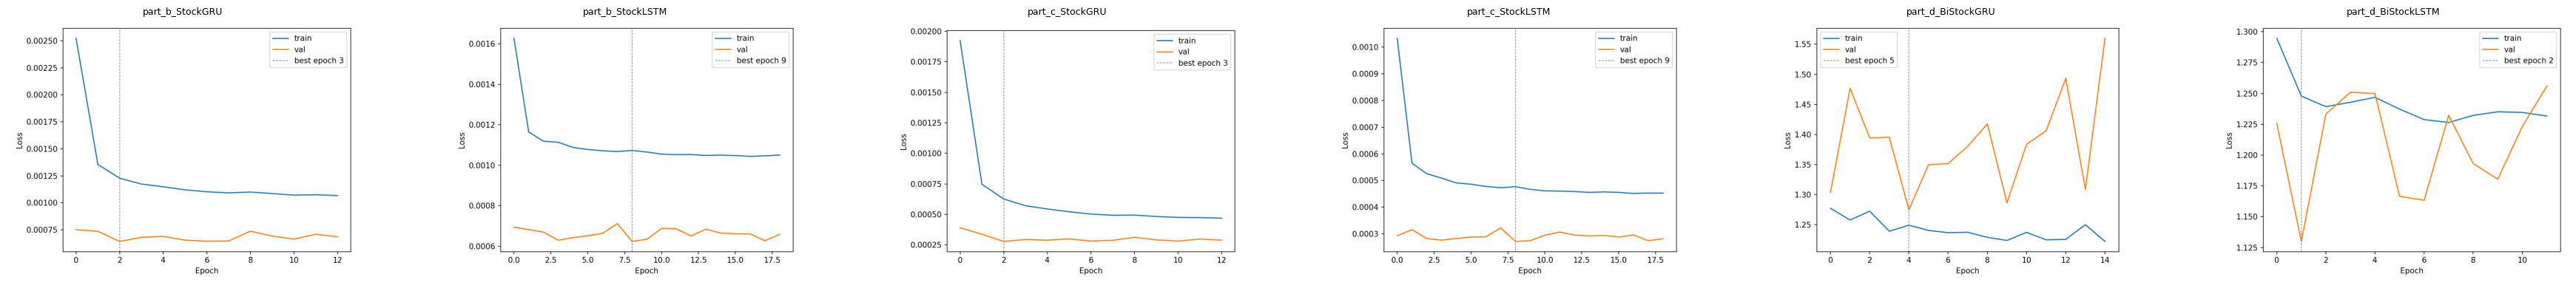

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots = sorted(glob.glob('results/hw4/plots/*.png'))
if not plots:
    print('Henüz plot yok.')
else:
    fig, axes = plt.subplots(1, len(plots), figsize=(6 * len(plots), 4))
    if len(plots) == 1:
        axes = [axes]
    for ax, path in zip(axes, plots):
        ax.imshow(mpimg.imread(path))
        ax.set_title(os.path.basename(path).replace('_loss.png', ''), fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 9. Sonuçları İndir

`results/hw4/` altındaki tüm dosyalar (metrikler, plotlar) tek zip olarak indirilir.  
Checkpointler büyük olduğu için dahil edilmez.

In [ ]:
import shutil
from google.colab import files

# Sadece metrics ve plots — checkpoints hariç
tmp_dir = '/tmp/hw4_results'
os.makedirs(tmp_dir, exist_ok=True)
for sub in ('metrics', 'plots'):
    shutil.copytree(f'results/hw4/{sub}', f'{tmp_dir}/{sub}', dirs_exist_ok=True)

zip_path = '/tmp/hw4_results'
shutil.make_archive(zip_path, 'zip', tmp_dir)
print('hw4_results.zip hazır, indiriliyor...')
files.download(zip_path + '.zip')